In [1]:
from jax import config
config.update("jax_enable_x64", True)
from pathlib import Path
import glob 

In [2]:
import matplotlib.pyplot as plt 
from spectres import spectres
import numpy as np
import jax.numpy as jnp 
import jax
import pickle 
import pandas as pd 
import numpy as np
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from astropy.io import fits
from astropy.table import Table

In [3]:
from sheap import Sheapectral
from sheap.Utils.SpectralReaders import parallel_reader 

from sheap.Utils.Paper import plot_logdex_agreement,log10_to_linear,posterior_extraction,bins_centered_on_zero,summary_similarity,compare_res
from sheap.Assistants.parser_mapper import get_multiple_sample_params,get_sample_params,summarize_spectral_lines

In [4]:
%load_ext autoreload
%autoreload 2

In [ ]:
base_panda = pd.read_csv(f"/DR16_[2.5, 2.75).csv")

In [ ]:
# This file can be found in the link {}
dr16_pandas = pd.read_csv("../../dr16q_prop_May01_2024_csv.csv")

In [8]:
mask = dr16_pandas['SDSS_NAME'].isin(base_panda['SDSS_NAME'])
fast_df = dr16_pandas[mask]

In [9]:
# Merge, keeping base_panda as reference
merged = base_panda.merge(
    fast_df,
    on="SDSS_NAME",
    how="left",
    suffixes=("", "_fast"),
)

# Drop duplicated columns coming from fast_df
cols_to_drop = [c for c in merged.columns if c.endswith("_fast")]
merged = merged.drop(columns=cols_to_drop)

# Preserve original order explicitly (merge already does, but this is bulletproof)
merged = merged.loc[base_panda.index]

In [10]:
merged.columns

Index(['SDSS_NAME', 'Z_DR16Q', 'Z_SYS', 'FHOST_5100', 'Z_FIT', 'PLATE', 'MJD',
       'FIBERID', 'RA', 'DEC', 'EBV', 'IF_BOSS_SDSS', 'SN_MEDIAN_ALL',
       'LOGL5100', 'LOGL1350', 'LOGL1700', 'LOGL2500', 'LOGL3000', 'LOGLBOL',
       'LOGMBH_HB', 'LOGMBH_MGII', 'LOGMBH_CIV', 'LOGMBH', 'LOGLEDD_RATIO',
       'NAXIS2', 'deltaz', 'zbin', 'SN_q', 'dr_name', 'fit_path', 'npix',
       'LOGL1350_ERR', 'LOGMBH_CIV_ERR', 'BAL_PROB', 'BI_CIV'],
      dtype='object')

In [11]:
#plt.hist(merged.BAL_PROB.values)

In [12]:
sheapspectral = Sheapectral.from_pickle("wushen22_montecarlo_rachi.pkl")
#result_pandas = posterior_extraction(sheapspectral,extra_key="extra_combined_pyqso")#extra_key="extra_combined_params")#extra_combined_pyqso

In [13]:
np.argsort(sheapspectral.result.chi2_red)[::-1]

array([498, 417, 402, 195, 305, 406, 454, 151, 430, 401, 383, 109, 365,
       190, 229, 464, 440,  67, 131,   7, 442, 128,  16,  31, 279,  19,
       303, 111, 148, 446, 124,  13, 485, 488, 259, 299, 172,  40,  50,
       312, 444,  61,  48, 486, 181, 294, 283, 142, 394,  20, 461, 453,
       392, 272, 304, 107, 101, 332, 449, 126, 257, 147,  66, 366, 325,
       185, 120, 344, 108,  84, 186, 212, 400, 263,  49,  30, 308, 246,
        39, 327, 320, 129, 216, 163, 207, 479,   6, 171, 285, 352, 369,
       422, 333, 152, 409, 307, 429, 390, 302, 261, 463, 329, 347,  93,
        42, 434, 254, 306,  15, 413, 110, 273, 340, 380, 244, 467, 336,
       160, 404, 316, 427,  18, 292,  21, 468, 496, 282, 361, 455,  46,
       188, 236, 196,  44, 255, 193, 145, 480, 387, 315, 326,  86,  99,
       396, 436, 277,  14, 378, 166, 135, 469, 465, 127,  45, 234, 433,
       231, 175, 493, 269, 460, 137, 389, 447, 224, 452,  62, 119,  27,
       408, 354, 278, 115, 431, 450, 407, 143, 492, 225,  83, 18

In [14]:
sheapspectral.result.chi2_red[186]

np.float32(10.059279)

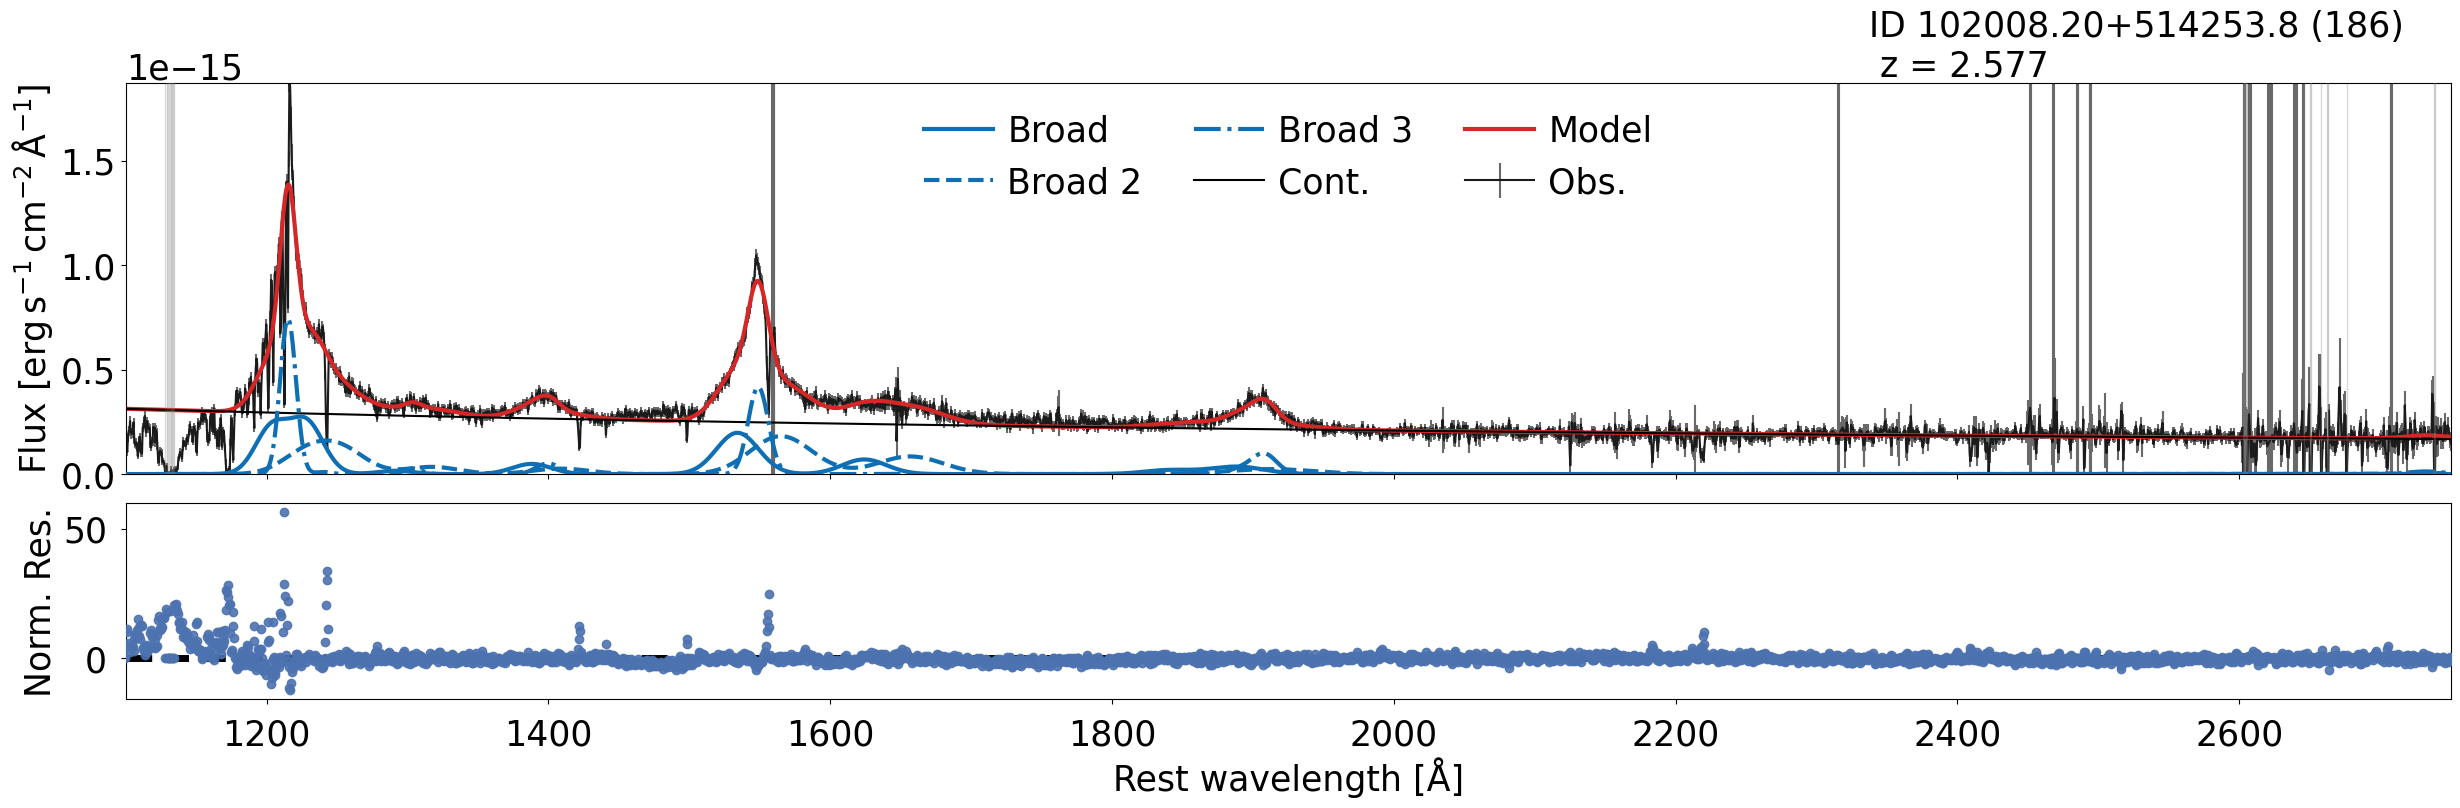

In [15]:
sheapspectral.modelplot.plot(186)

In [16]:
np.argsort(sheapspectral.result.chi2_red)[::-1]

array([498, 417, 402, 195, 305, 406, 454, 151, 430, 401, 383, 109, 365,
       190, 229, 464, 440,  67, 131,   7, 442, 128,  16,  31, 279,  19,
       303, 111, 148, 446, 124,  13, 485, 488, 259, 299, 172,  40,  50,
       312, 444,  61,  48, 486, 181, 294, 283, 142, 394,  20, 461, 453,
       392, 272, 304, 107, 101, 332, 449, 126, 257, 147,  66, 366, 325,
       185, 120, 344, 108,  84, 186, 212, 400, 263,  49,  30, 308, 246,
        39, 327, 320, 129, 216, 163, 207, 479,   6, 171, 285, 352, 369,
       422, 333, 152, 409, 307, 429, 390, 302, 261, 463, 329, 347,  93,
        42, 434, 254, 306,  15, 413, 110, 273, 340, 380, 244, 467, 336,
       160, 404, 316, 427,  18, 292,  21, 468, 496, 282, 361, 455,  46,
       188, 236, 196,  44, 255, 193, 145, 480, 387, 315, 326,  86,  99,
       396, 436, 277,  14, 378, 166, 135, 469, 465, 127,  45, 234, 433,
       231, 175, 493, 269, 460, 137, 389, 447, 224, 452,  62, 119,  27,
       408, 354, 278, 115, 431, 450, 407, 143, 492, 225,  83, 18

In [17]:
# merged.BI_CIV.values[417]

In [18]:
# np.argsort(merged.BI_CIV.values)[::-1]

In [19]:
sheapspectral.result.chi2_red

array([ 3.9433038,  1.9043765,  1.504316 ,  1.8623072,  4.010071 ,
        1.6369241,  9.254479 , 23.53923  ,  2.735978 ,  2.738492 ,
        2.2163582,  3.1368222,  2.3168938, 18.647486 ,  6.1703105,
        7.780759 , 21.27345  ,  2.6747046,  7.221737 , 20.45403  ,
       13.15525  ,  7.07634  ,  1.3934897,  4.039754 ,  2.271479 ,
        2.3334644,  3.5203497,  5.5980587,  3.3117406,  3.369026 ,
        9.971832 , 21.046885 ,  2.5284963,  2.2781312,  2.9861476,
        3.1998935,  4.1375093,  1.8301684,  2.734825 ,  9.812667 ,
       16.96249  ,  4.8612776,  7.969141 ,  2.7508297,  6.565779 ,
        6.0140047,  6.9097824,  3.649829 , 14.439038 ,  9.995519 ,
       15.54273  ,  5.1528425,  3.7107887,  3.3585844,  4.293288 ,
        1.9390432,  1.8666142,  2.931908 ,  4.0842443,  3.310938 ,
        4.237355 , 14.796651 ,  5.7269835,  4.1973567,  2.5340486,
        5.2224   , 10.533083 , 23.832483 ,  1.8620062,  3.6212835,
        2.4848273,  2.52291  ,  3.7519066,  2.6021616,  3.7152

In [38]:
sheapspectral.result.posterior["montecarlo"].keys()

dict_keys(['posterior_result', 'num_samples', 'key_seed', 'summarize', 'time_elapsed'])

In [39]:
df_extra = posterior_extraction(
     sheapspectral,
     posterior_idx=1,
     extra_key="extra_params_combined_classical",
 )

mask = (
    (df_extra["line"] == "CIV") &
    (df_extra["SMBHEstimator"] == "VP06_CIV_1350") &
    (df_extra["quantity"] == "vwidth_kms")
)

CIV_FWHM_median = df_extra.loc[mask, "median"].to_numpy().flatten().astype(float)
CIV_FWHM_err_plus = df_extra.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
CIV_FWHM_err_minus = df_extra.loc[mask, "err_minus"].to_numpy().flatten().astype(float)

mask = (
    (df_extra["line"] == "CIV") &
    (df_extra["SMBHEstimator"] == "VP06_CIV_1350") &
    (df_extra["quantity"] == "Lwave")
)

CIV_Lwave_median = df_extra.loc[mask, "median"].to_numpy().flatten().astype(float)
CIV_Lwave_err_plus = df_extra.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
CIV_Lwave_err_minus = df_extra.loc[mask, "err_minus"].to_numpy().flatten().astype(float)

# mask = (
#     (df_extra["line"] == "Halpha") &
#     (df_extra["SMBHEstimator"] == "RV15_Halpha_Lha") &
#     (df_extra["quantity"] == "Lline")
# )

# # All Ledd medians:
# Halpha_Lline_median = df_extra.loc[mask, "median"].to_numpy().flatten().astype(float)
# Halpha_Lline_err_plus = df_extra.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
# Halpha_Lline_err_minus = df_extra.loc[mask, "err_minus"].to_numpy().flatten().astype(float)



#'extra_combined_params', 'extra_combined_pyqso'
# CIV_FWHM = pd.DataFrame([{"name": key,**values["extra_combined_pyqso"]["CIV"]["VP06_CIV_1350"]["vwidth_kms"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values
# L1350_SHEAP = pd.DataFrame([{"name": key,**values["extra_combined_pyqso"]["CIV"]["VP06_CIV_1350"]["Lwave"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values
# LOGMBH_CIV_sheap =  pd.DataFrame([{"name": key,**values["extra_combined_pyqso"]["CIV"]["VP06_CIV_1350"]["log10_smbh"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values

/share/cav/data/favila/smbh_mass/sheap/sheap/Utils/Paper.py:159: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [40]:
from uncertainties import unumpy as unp
LOGMBH_CIV = unp.uarray(merged.LOGMBH_CIV.values,merged.LOGMBH_CIV_ERR.values)
LOGL1350 = unp.uarray(merged.LOGL1350.values,merged.LOGL1350_ERR.values)

(a, b, c) = (6.660, 0.53, 2.0)

CIV_fwhm = 10**((LOGMBH_CIV - unp.log10(1) - a - b * unp.log10(10**LOGL1350/1e44))/c) *1e3

CIV_fwhm_val = unp.nominal_values(CIV_fwhm)
CIV_fwhm_error   = unp.std_devs(CIV_fwhm)

L1350_val = unp.nominal_values(10**LOGL1350)
L1350_error   = unp.std_devs(10**LOGL1350)

In [41]:
# CIV_fwhm_error

In [42]:
# MBH_CIV,MBH_CIV_err_minus, MBH_CIV_err_plus = log10_to_linear(merged.LOGMBH_CIV.values,merged.LOGMBH_CIV_ERR.values)
# L1350,L1350_err_minus, L1350_err_plus = log10_to_linear(merged.LOGL1350.values,merged.LOGL1350_ERR.values)

# (a, b, c) = (6.660, 0.53, 2.0)

# CIV_fwhm = 10**((LOGMBH_CIV - np.log10(1) - a - b * np.log10(10**LOGL1350/1e44))/c) *1e3

In [43]:
CIV_FWHM_err_plus[0]

np.float64(315.2956640624998)

In [44]:
# (CIV_fwhm_val+CIV_fwhm_error)[0]

In [45]:
# _ = plot_logdex_agreement(data_dict,lims=[2.9,4.3],
# 							 ref_label="MgII",label_mode="fwhm_clasic",ref_work="Pan+25",add_numbers=False,colors=("#000000", "#fd0404f8"),
# 							 text=text,sn=sheapspectral.snr,save_file=save_file,label_colorbar="S/N",markers= ('s','o'))#)

Bad errors minus in index [ 93 356 430] 100% error


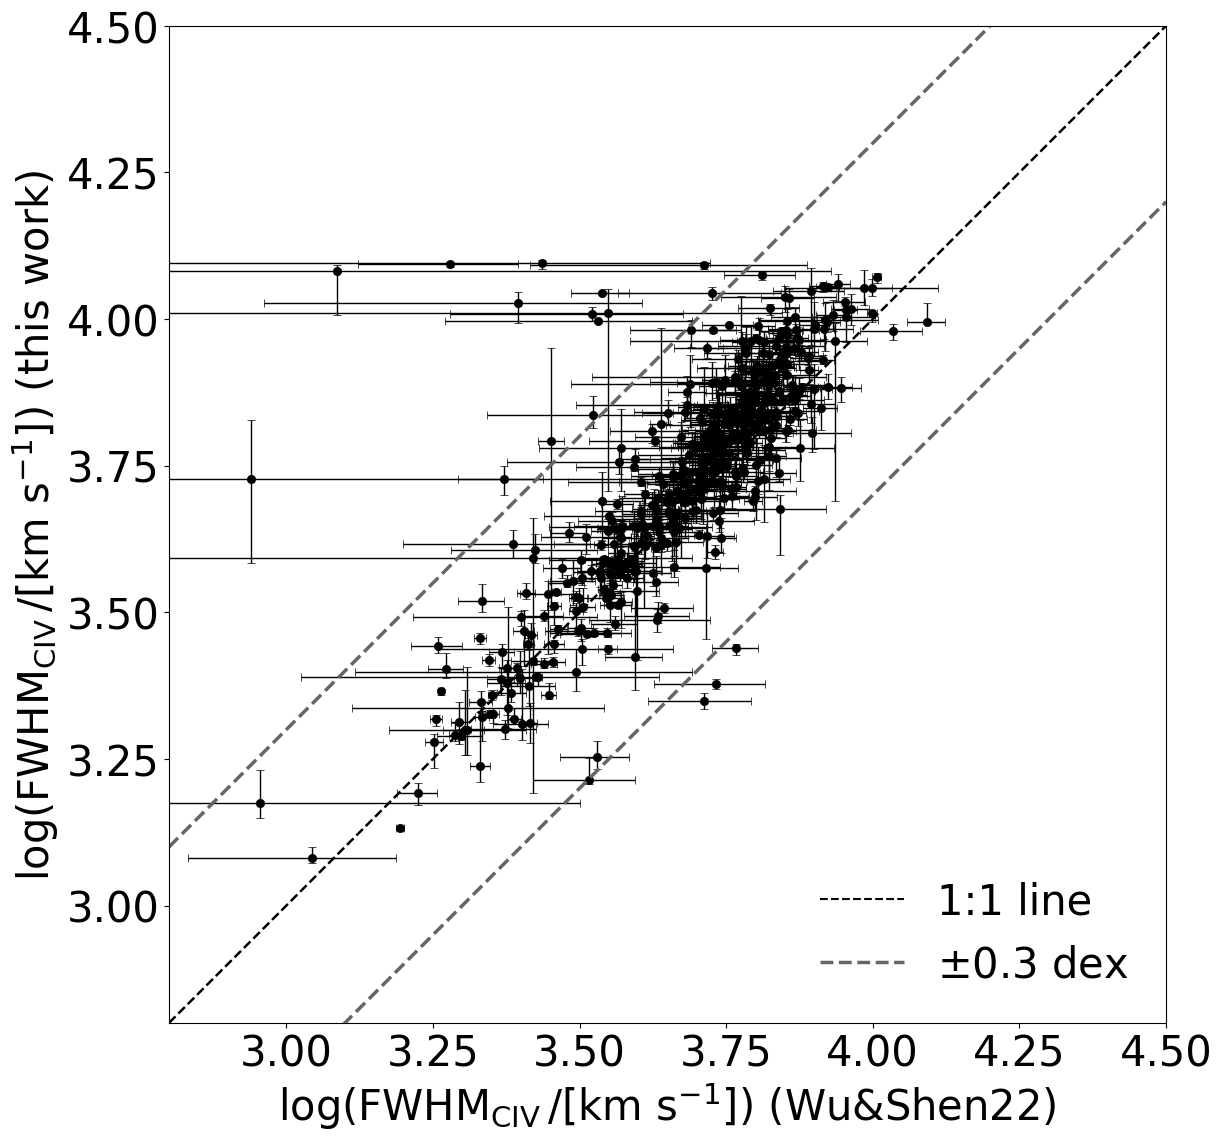

In [46]:
data_dict = {
    r"Values Wu&Shen22": {
        "x": np.vstack([CIV_fwhm_val,CIV_fwhm_error]),          # (2, N) symmetric error
        "y": np.vstack([CIV_FWHM_median,CIV_FWHM_err_plus,CIV_FWHM_err_minus]),  # (3, N) +/-
    },}

text = None#{"text":"CIV FWHM Combined","xpos":0.3,"ypos":0.95}
sn= None#sheapspectral.snr 
(_,_,fwhm,_)=plot_logdex_agreement(data_dict,lims=[2.8,4.5],ref_label="C IV",label_mode="fwhm_clasic",ref_work="Wu&Shen22",add_numbers=False,colors=(
        "black", "#7f7f7f"),sn=sn,label_colorbar="S/N",remove_scater_legend=True,text=text,save_file="images/fwhm_compare_wushen22.pdf")#)

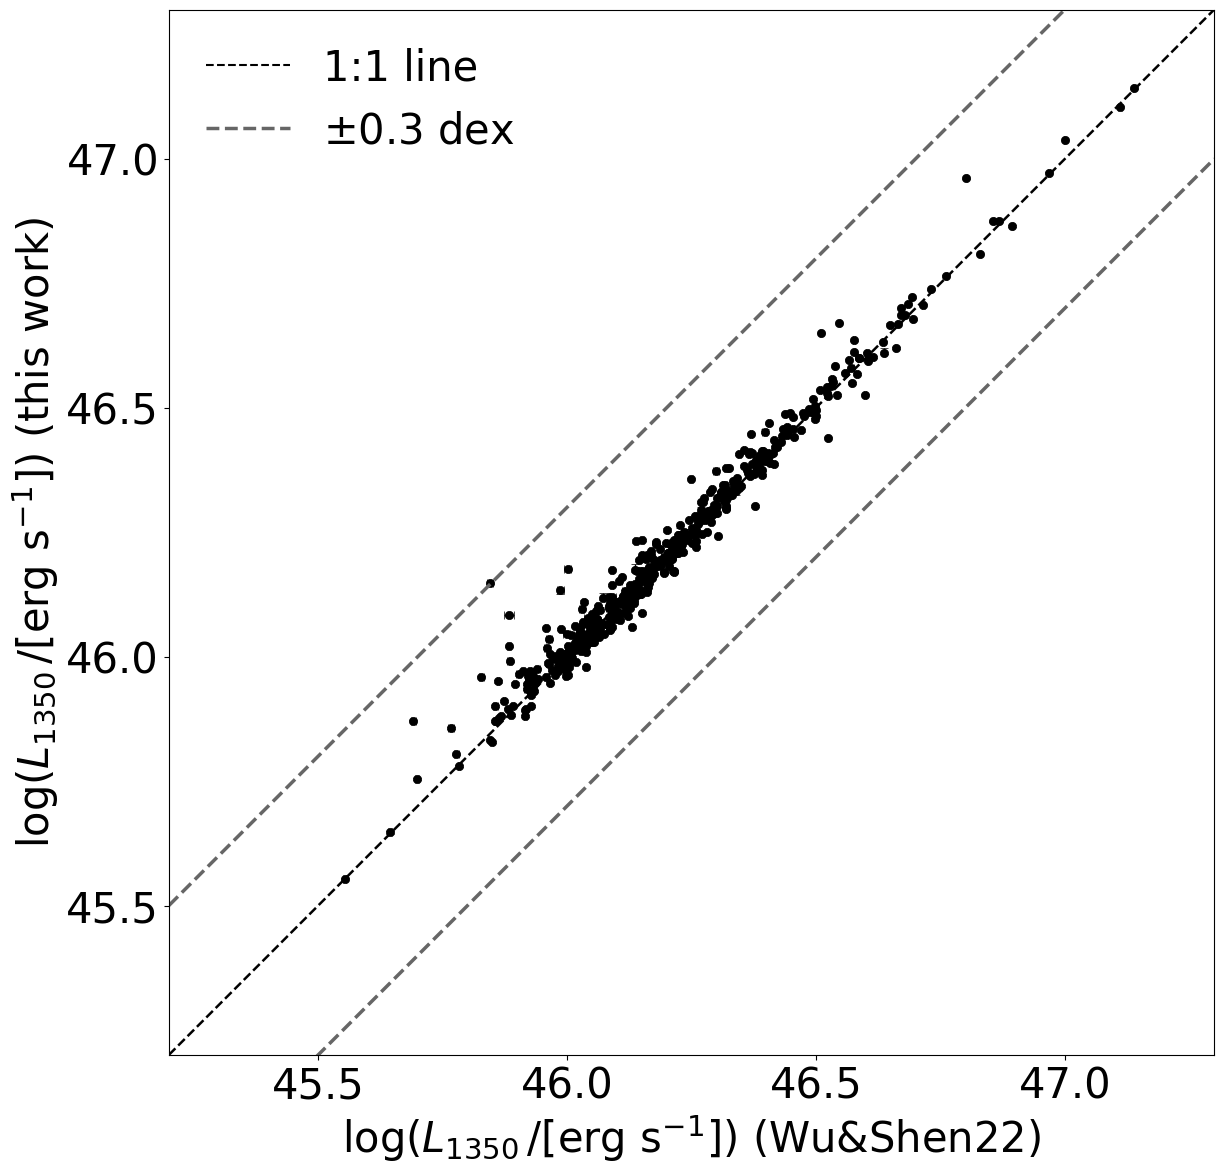

In [48]:
data_dict = {
    r"Values Wu&Shen22": {
        "x": np.vstack([L1350_val,L1350_error]),          # (2, N) symmetric error
        "y": np.vstack([CIV_Lwave_median,CIV_Lwave_err_plus,CIV_Lwave_err_minus]),  # (3, N) +/-
    },}
#outlier - > 1.
text = None#{"text":r"$\lambda L_{\lambda}(1350\,\AA)$","xpos":0.8,"ypos":0.25}
# continuum_stuf = plot_logdex_agreement(data_dict,lims=[44.5,46.8],ref_label="3000",label_mode="l_clasic",ref_work="Pan+25"
# 										  ,add_numbers=False,colors=( "#fd0404f8","#000000"),save_file=save_file,legend_loc="upper left",sn=sheapspectral.snr,label_colorbar="S/N"
# 										  ,ref_wavelenght=3000,text=text)
sn=None#sheapspectral.snr
(_,_,L,_)=plot_logdex_agreement(data_dict,ref_label="1350",label_mode="l_clasic",ref_work="Wu&Shen22",remove_scater_legend=True,lims= [45.2,47.3]
                                ,add_numbers=False,colors=("black", "#7f7f7f"),legend_loc="upper left",save_file="images/Lcont_compare_wushen22.pdf",sn=sn,
                             label_colorbar="S/N",ref_wavelenght=1350,text=text)

In [49]:
dictionaries = [fwhm, L]
for i in dictionaries:
	print(i.keys())

dict_keys(['Values Wu&Shen22'])
dict_keys(['Values Wu&Shen22'])


FWHM$_{\rm C\,IV}$: N=500, band=±0.300 dex, f_within=96.400, bias_med=0.041 dexNMAD=0.066 dex SHEAP larger in 9.83%
$L_{1350}$: N=500, band=±0.300 dex, f_within=99.800, bias_med=0.005 dexNMAD=0.021 dex SHEAP larger in 1.23%


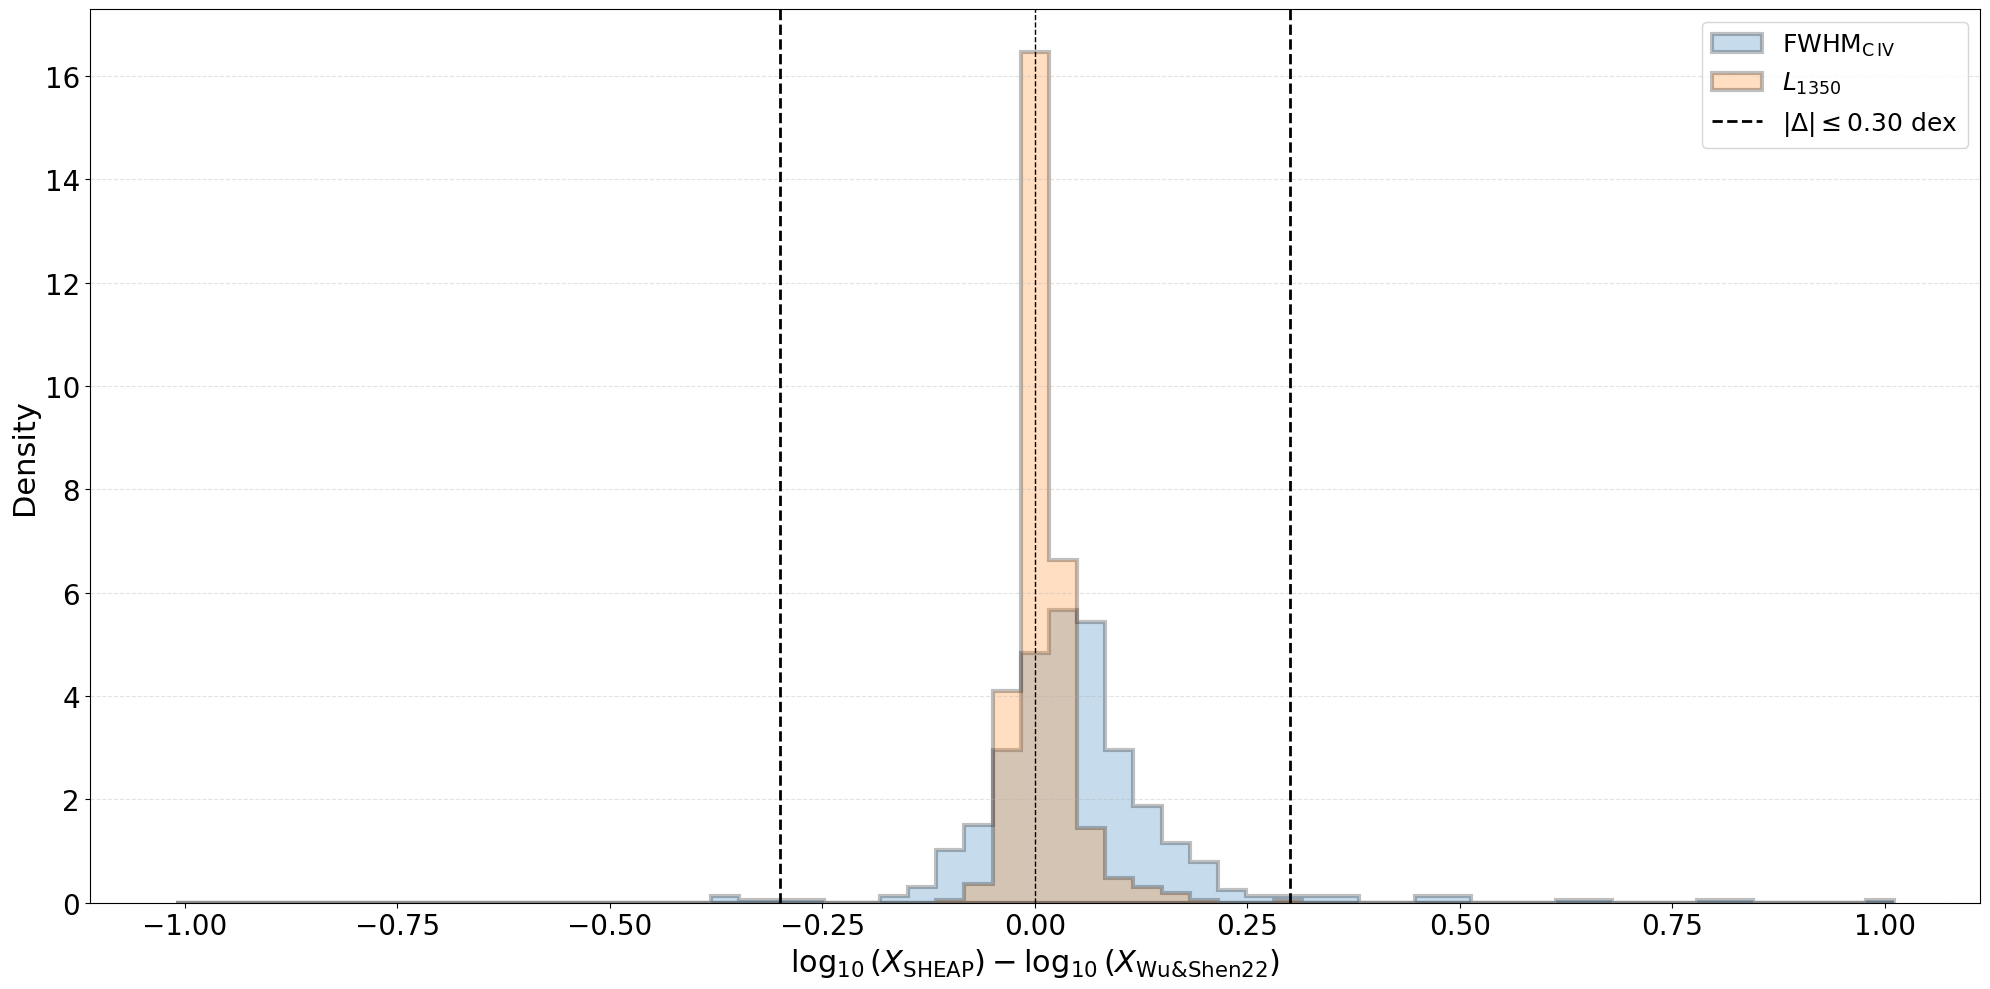

In [50]:
dictionaries = [fwhm, L]
labels = [r"FWHM$_{\rm C\,IV}$",r"$L_{1350}$"]
labels_p = [r"FWHM$_{\rm C\,IV}$",r"$L_{1350}$"]
main_key_list = ['Values Wu&Shen22']
compare_res(dictionaries,labels,compared_xlabel="Wu&Shen22",save_file="images/res_distribution.pdf",main_key='Values Wu&Shen22')

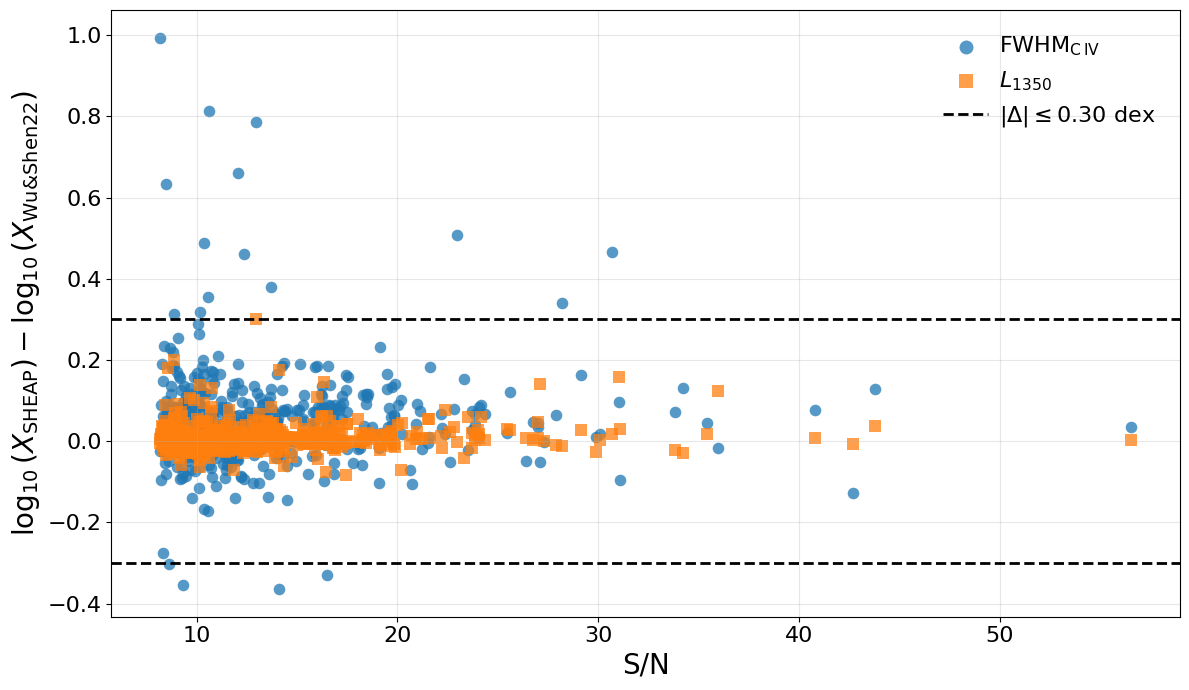

In [51]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

#main_key = "Values Pan+25"
#labels_p = [r"FWHM$_{\rm Mg\,II}$",r"$L_{3000}$",r"$(F_{\rm Fe\,II}/F_{\rm Mg\,II})$"]
#main_key_list = ["DAS values","FSF values",'FSF (h=0.7)',"DAS"]
markers = ["o", "s", "^", "D", "D", "D"]

# --- Font / style knobs ---
fs_label  = 20
fs_ticks  = 16
fs_legend = 16
marker_size = 70
alpha_val = 0.75

# --- Collect exactly-plotted data here ---
plot_data = {}  # plot_data[label] = {"x": x_plotted, "y": y_plotted}

fig, ax = plt.subplots(figsize=(12, 7))
jj = 0 
for nn, D in enumerate(dictionaries):
	#res = dd[main_key]["res"]
	X = [val for k in main_key_list for val in [D.get(k, {}).get("res")] if val is not None]
	mask = [val for k in main_key_list for val in [D.get(k, {}).get("is_finite")] if val is not None]
	sub_label = [k for k in main_key_list for val in [D.get(k, {}).get("res")] if val is not None]
	#s_local = labels_p[nn]
	for ii,res in enumerate(X):
		s_local = labels_p[jj]
  		#local_ = sub_label[ii].replace("values","")
		#print(summary_similarity(D[sub_label[ii]], name=f"{s_local} {local_}"))
		x_plot = sheapspectral.snr[mask[ii]]
		y_plot = res
		plot_data[s_local] = {
		"x": x_plot,
		"y": y_plot,
		"marker": markers[nn],
		#"main_key": main_key,
		}

		ax.scatter(
			x_plot, y_plot,
			marker=markers[nn],
			s=marker_size,
			alpha=alpha_val,
			label=s_local,
			linewidths=0.0
		)
		jj += 1
	#snr_local = sheapspectral.snr#[mask_local]

	#if len(res) != len(snr_local):
	 #   raise ValueError(f"Length mismatch: res={len(res)} vs snr_local={len(snr_local)}")

	#ok = np.isfinite(snr_local) & np.isfinite(res)

	# these are the ONLY points that go to the scatter


	

ax.axhline(0.3, linestyle="--", linewidth=2,c="k")
ax.axhline(-0.3, linestyle="--", linewidth=2,c="k",label=rf"$|\Delta|\leq {0.3:.2f}\ \mathrm{{dex}}$")

ax.set_xlabel("S/N", fontsize=fs_label)
ax.set_ylabel(r"$\log_{10}(X_{\rm SHEAP}) - \log_{10}(X_{\rm Wu&Shen22})$", fontsize=fs_label)
ax.tick_params(axis="both", which="major", labelsize=fs_ticks)
ax.tick_params(axis="both", which="minor", labelsize=fs_ticks - 2)
ax.grid(True, alpha=0.3)

ax.legend(
	fontsize=fs_legend,
	frameon=False,
	loc="best",
	markerscale=1.2,
	handletextpad=0.5,
	borderpad=0.6
)

plt.tight_layout()
plt.savefig("images/signal_2_noise_vs_res_wushen.pdf", dpi=300, format="pdf", bbox_inches="tight")
plt.show()

# --- Save the plotted x/y to pickle ---
os.makedirs("images", exist_ok=True)
pkl_path = "images/signal_2_noise_vs_res_wushen.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(plot_data, f, protocol=pickle.HIGHEST_PROTOCOL)

#print(f"Saved plotted x/y to: {pkl_path}")
